In [68]:
import os
import numpy as np
import cv2
import PIL
import matplotlib.pyplot as plt
from tensorflow import keras
import tensorflow as tf
import tensorflow_hub as hub

In [69]:
import tf_keras as tfk
IMAGE_SHAPE = (224, 224)
classifier = tfk.Sequential([
    hub.KerasLayer("https://www.kaggle.com/models/google/mobilenet-v2/TensorFlow2/050-224-classification/2", input_shape=IMAGE_SHAPE+(3,))
])

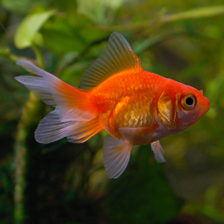

In [70]:
gold_fish = PIL.Image.open(r"D:\goldfish.jpg").resize(IMAGE_SHAPE)
gold_fish

In [71]:
gold_fish = np.array(gold_fish)
gold_fish = gold_fish/255
gold_fish

array([[[0.28235294, 0.33333333, 0.07058824],
        [0.31372549, 0.37254902, 0.09019608],
        [0.34901961, 0.41960784, 0.11764706],
        ...,
        [0.32941176, 0.39215686, 0.00392157],
        [0.32156863, 0.38431373, 0.00392157],
        [0.30980392, 0.36862745, 0.        ]],

       [[0.28627451, 0.33333333, 0.08235294],
        [0.3254902 , 0.38039216, 0.10980392],
        [0.35294118, 0.42352941, 0.12941176],
        ...,
        [0.32156863, 0.38039216, 0.00392157],
        [0.31372549, 0.37254902, 0.00392157],
        [0.30196078, 0.36078431, 0.        ]],

       [[0.28627451, 0.33333333, 0.08627451],
        [0.31372549, 0.36862745, 0.10196078],
        [0.34509804, 0.41568627, 0.12941176],
        ...,
        [0.31764706, 0.37647059, 0.00392157],
        [0.30980392, 0.36862745, 0.00784314],
        [0.29803922, 0.35686275, 0.00392157]],

       ...,

       [[0.05490196, 0.10980392, 0.01568627],
        [0.05098039, 0.11372549, 0.01960784],
        [0.05098039, 0

In [72]:
gold_fish[np.newaxis, ...].shape

(1, 224, 224, 3)

In [73]:
result = classifier.predict(gold_fish[np.newaxis, ...])
result

1/1 [==============================] - 1s 721ms/step


array([[ 0.38737667,  5.1115646 , 11.536192  , ..., -0.9016145 ,
        -0.18741925,  0.19210535]], shape=(1, 1001), dtype=float32)

In [74]:
predicted_labels_index = np.argmax(result)
predicted_labels_index

np.int64(2)

In [75]:
image_labels = []
with open (r"D:\ImageNetLabels.txt") as f:
    image_labels = f.readlines()

In [76]:
image_labels[:5]

['background\n',
 'tench\n',
 'goldfish\n',
 'great white shark\n',
 'tiger shark\n']

In [77]:
image_labels[predicted_labels_index]

'goldfish\n'

In [78]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file("flower_photos", origin=dataset_url, cache_dir=".", untar=True)

In [79]:
data_dir

'.\\datasets\\flower_photos'

In [80]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

WindowsPath('datasets/flower_photos')

In [81]:
list(data_dir.rglob("*/*.jpg"))

[WindowsPath('datasets/flower_photos/flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172379554_b296050f82_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172567486_2748826a8b.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172636503_21bededa75_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/102841525_bd6628ae3c.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/1031799732_e7f4008c03.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10391248763_1d16681106_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10437754174_22ec990b77_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10437770546_8bb6f7bdd3_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10437929963_bc13eebe0c.jpg'),
 WindowsPath('datasets/flower_photos

In [82]:
image_count = len(list(data_dir.rglob("*/*.jpg")))
image_count

3670

In [83]:
roses = list(data_dir.rglob("roses/*"))
roses[:5]

[WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

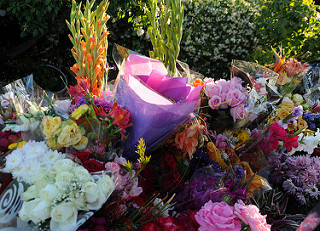

In [84]:
PIL.Image.open(roses[3])

In [85]:
tulips = list(data_dir.rglob("tulips/*"))
tulips[:5]

[WindowsPath('datasets/flower_photos/flower_photos/tulips/100930342_92e8746431_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/tulips/10094729603_eeca3f2cb6.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/tulips/10094731133_94a942463c.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/tulips/10128546863_8de70c610d.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/tulips/10163955604_ae0b830975_n.jpg')]

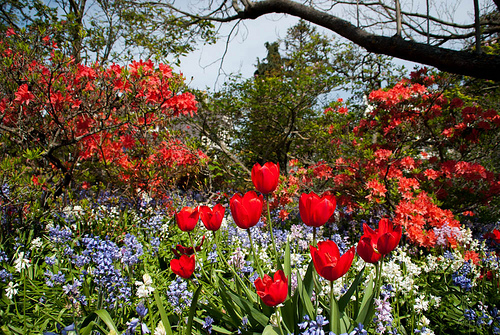

In [86]:
PIL.Image.open(tulips[5])

In [87]:
flowers_images_dict = {
    "roses" : list(data_dir.rglob("roses/*")),
    "daisy" : list(data_dir.rglob("daisy/*")),
    "dandelion" : list(data_dir.rglob("dandelion/*")),
    "sunflowers" : list(data_dir.rglob("sunflowers/*")),
    "tulips" : list(data_dir.rglob("tulips/*"))
}

In [88]:
flowers_images_dict["roses"][:5]

[WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

In [89]:
flowers_labels_dict = {
    "roses" : 0,
    "daisy" : 1,
    "dandelion" : 2,
    "sunflowers" : 3,
    "tulips" : 4
}

In [90]:
img = cv2.imread(str(flowers_images_dict["roses"][0]))
img.shape

(240, 179, 3)

In [91]:
cv2.resize(img, IMAGE_SHAPE).shape

(224, 224, 3)

In [92]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_image = cv2.resize(img, IMAGE_SHAPE)
        X.append(resized_image)
        y.append(flowers_labels_dict[flower_name])

In [93]:
X = np.array(X)
y = np.array(y)

In [94]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

In [95]:
X_train = X_train/255
y_train = y_train/255

In [96]:
X_train[0]

array([[[0.85882353, 0.89019608, 0.95686275],
        [0.8627451 , 0.89411765, 0.96078431],
        [0.85098039, 0.89019608, 0.95686275],
        ...,
        [0.85490196, 0.89411765, 0.96470588],
        [0.85490196, 0.89411765, 0.96470588],
        [0.84705882, 0.88627451, 0.95686275]],

       [[0.85490196, 0.88627451, 0.95294118],
        [0.85490196, 0.88627451, 0.95294118],
        [0.85490196, 0.89019608, 0.95686275],
        ...,
        [0.85490196, 0.89411765, 0.96470588],
        [0.85490196, 0.89411765, 0.96470588],
        [0.85098039, 0.89019608, 0.96078431]],

       [[0.85098039, 0.88235294, 0.94901961],
        [0.85098039, 0.88235294, 0.94901961],
        [0.85490196, 0.88627451, 0.95294118],
        ...,
        [0.85098039, 0.89019608, 0.96470588],
        [0.84705882, 0.88235294, 0.95686275],
        [0.84705882, 0.88235294, 0.95294118]],

       ...,

       [[0.02745098, 0.53333333, 0.59215686],
        [0.02745098, 0.56862745, 0.64313725],
        [0.05098039, 0

In [97]:
y_train[0]

np.float64(0.011764705882352941)

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

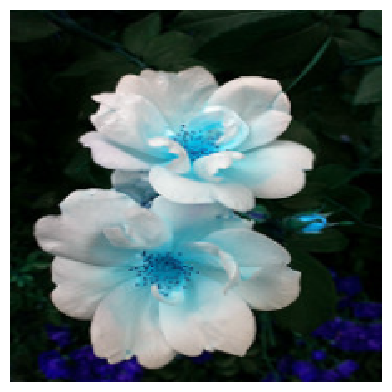

In [98]:
plt.matshow(X[0])
plt.axis("off")

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

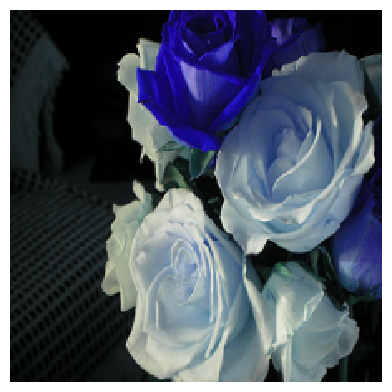

In [99]:
plt.matshow(X[1])
plt.axis("off")

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

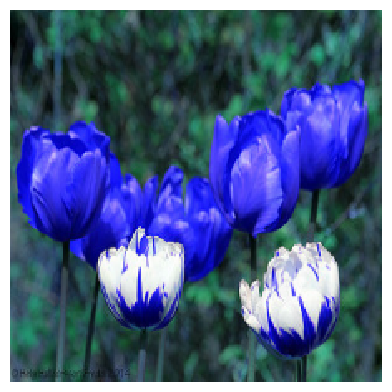

In [100]:
plt.matshow(X[50])
plt.axis("off")

In [101]:
predicted = classifier.predict(np.array([X[0], X[1], X[2]]))
predicted = np.argmax(predicted, axis=1)
predicted

1/1 [==============================] - 5s 5s/step


array([489, 880, 534])

In [102]:
image_labels[880]

'umbrella\n'

**As we can saw that readymade model is making the weird predictions not as accurate as it is limited on those only 1000 images**

In [103]:
feature_extractor_model = "https://www.kaggle.com/models/google/mobilenet-v2/TensorFlow2/035-224-feature-vector/2"
model_without_classification = hub.KerasLayer(feature_extractor_model, input_shape=(224, 224, 3), trainable=False)

In [104]:
model = tfk.Sequential([
    model_without_classification,
    tfk.layers.Dense(5, activation="sigmoid")
])

model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_3 (KerasLayer)  (None, 1280)              410208    
                                                                 
 dense_1 (Dense)             (None, 5)                 6405      
                                                                 
Total params: 416613 (1.59 MB)
Trainable params: 6405 (25.02 KB)
Non-trainable params: 410208 (1.56 MB)
_________________________________________________________________


In [105]:
model.compile(optimizer="adam", loss=tfk.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=["accuracy"])
model.fit(X_train, y_train, epochs=5)

Epoch 1/5


d:\Deep Learning\venv\Lib\site-packages\tf_keras\src\backend.py:5729: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


86/86 [==============================] - 40s 344ms/step - loss: 0.0517 - accuracy: 0.1704
Epoch 2/5
86/86 [==============================] - 21s 240ms/step - loss: 6.4203e-04 - accuracy: 0.1741
Epoch 3/5
86/86 [==============================] - 16s 181ms/step - loss: 4.7875e-04 - accuracy: 0.1741
Epoch 4/5
86/86 [==============================] - 18s 211ms/step - loss: 3.6422e-04 - accuracy: 0.1741
Epoch 5/5
86/86 [==============================] - 17s 193ms/step - loss: 2.8394e-04 - accuracy: 0.1741


In [106]:
model.evaluate(X_test, y_test)

29/29 [==============================] - 10s 232ms/step - loss: 7.5760 - accuracy: 0.1765


[7.576033115386963, 0.1764705926179886]